# AI-Based Smart Power Usage Prediction System

## Abstract
This notebook implements a short-term electricity usage prediction prototype using historical electrical measurements, with emphasis on voltage and current as core predictors. We preprocess time-series data, train multiple machine learning regressors, evaluate performance using MAE, RMSE, and R², and visualize predicted vs actual consumption and peak-demand periods.

## Objectives
- Build a reliable short-term power forecasting model
- Compare baseline and ensemble regressors
- Provide actionable peak-demand insights for planning and scheduling

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42

In [ ]:
!pip install -q ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
individual_household_electric_power_consumption = fetch_ucirepo(id=235) 
  
# data (as pandas dataframes) 
raw_df = individual_household_electric_power_consumption.data.features 
  
# metadata 
print(individual_household_electric_power_consumption.metadata) 
  
# variable information 
print(individual_household_electric_power_consumption.variables) 


KeyboardInterrupt: 

In [ ]:
X.head()

In [ ]:
y.head()

In [ ]:
raw_df = pd.concat((X,y), axis='columns')

In [12]:
DATASET_NAME = "household_power_consumption.csv"
candidate_paths = [
    Path(f"./data/{DATASET_NAME}"),
    Path(f"./AI/data/{DATASET_NAME}"),
    Path(f"/home/temi/Documents/ML/AI/data/{DATASET_NAME}"),
    Path(f"/content/{DATASET_NAME}")
]

for p in candidate_paths:
    if p.exists():
        data_path = p
        break
else:
    raise FileNotFoundError("Could not locate household_power_consumption.csv")

raw_df = pd.read_csv(data_path, sep=";", na_values=["?"])
print(f"Loaded data from: {data_path}")
print(f"Shape: {raw_df.shape}")
raw_df.head()

Loaded data from: data/household_power_consumption.csv
Shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
df = raw_df.copy()

df["datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    dayfirst=True,
    errors="coerce",
)

numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(
    subset=["datetime", "Global_active_power", "Voltage", "Global_intensity"]
)
df = df.sort_values("datetime")

df_hourly = (
    df.set_index("datetime")[["Global_active_power", "Voltage", "Global_intensity"]]
    .resample("h")
    .mean()
    .dropna()
)

print("Hourly dataset shape:", df_hourly.shape)
df_hourly.head()

Hourly dataset shape: (34168, 3)


,Global_active_power,Voltage,Global_intensity
datetime,,,
2006-12-16 17:00:00,4.222889,234.643889,18.100000
2006-12-16 18:00:00,3.632200,234.580167,15.600000
2006-12-16 19:00:00,3.400233,233.232500,14.503333
2006-12-16 20:00:00,3.268567,234.071500,13.916667
2006-12-16 21:00:00,3.056467,237.158667,13.046667


In [4]:
model_df = df_hourly.copy()

# Forecast horizon: predict next-hour active power
model_df["target_next_hour"] = model_df["Global_active_power"].shift(-1)

# Time-based features
model_df["hour"] = model_df.index.hour
model_df["day_of_week"] = model_df.index.dayofweek
model_df["month"] = model_df.index.month
model_df["is_weekend"] = (model_df["day_of_week"] >= 5).astype(int)

# Lag features for historical patterns
for lag in [1, 2, 3, 6, 12, 24]:
    model_df[f"power_lag_{lag}"] = model_df["Global_active_power"].shift(lag)
    model_df[f"voltage_lag_{lag}"] = model_df["Voltage"].shift(lag)
    model_df[f"current_lag_{lag}"] = model_df["Global_intensity"].shift(lag)

# Rolling statistics (historical smoothing)
for window in [3, 6, 24]:
    model_df[f"power_roll_mean_{window}"] = (
        model_df["Global_active_power"].rolling(window).mean()
    )
    model_df[f"current_roll_mean_{window}"] = (
        model_df["Global_intensity"].rolling(window).mean()
    )

model_df = model_df.dropna()

print("Model-ready shape:", model_df.shape)
model_df.head()

Model-ready shape: (34143, 32)


,Global_active_power,Voltage,Global_intensity,target_next_hour,hour,day_of_week,month,is_weekend,power_lag_1,voltage_lag_1,current_lag_1,power_lag_2,voltage_lag_2,current_lag_2,power_lag_3,voltage_lag_3,current_lag_3,power_lag_6,voltage_lag_6,current_lag_6,power_lag_12,voltage_lag_12,current_lag_12,power_lag_24,voltage_lag_24,current_lag_24,power_roll_mean_3,current_roll_mean_3,power_roll_mean_6,current_roll_mean_6,power_roll_mean_24,current_roll_mean_24
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,234.229833,14.510000,3.697100,17,6,12,1,3.326033,236.781833,14.006667,2.985400,240.480833,12.426667,2.092633,244.045667,8.600000,2.471000,236.924667,10.493333,1.996733,243.710167,8.566667,4.222889,234.643889,18.100000,3.239400,13.647778,2.564578,10.767222,2.465140,10.492639
2006-12-17 18:00:00,3.697100,234.372333,15.750000,2.908400,18,6,12,1,3.406767,234.229833,14.510000,3.326033,236.781833,14.006667,2.985400,240.480833,12.426667,1.915867,237.784667,8.136667,1.303300,244.141500,5.530000,3.632200,234.580167,15.600000,3.476633,14.755556,2.861450,12.036111,2.467844,10.498889
2006-12-17 19:00:00,2.908400,233.195667,12.516667,3.361500,19,6,12,1,3.697100,234.372333,15.750000,3.406767,234.229833,14.510000,3.326033,236.781833,14.006667,1.660767,239.920667,6.923333,1.620033,241.845667,6.803333,3.400233,233.232500,14.503333,3.337422,14.258889,3.069389,12.968333,2.447351,10.416111
2006-12-17 20:00:00,3.361500,236.426500,14.276667,3.040767,20,6,12,1,2.908400,233.195667,12.516667,3.697100,234.372333,15.750000,3.406767,234.229833,14.510000,2.092633,244.045667,8.600000,1.890567,241.311500,8.050000,3.268567,234.071500,13.916667,3.322333,14.181111,3.280867,13.914444,2.451224,10.431111
2006-12-17 21:00:00,3.040767,239.104167,12.716667,1.518000,21,6,12,1,3.361500,236.426500,14.276667,2.908400,233.195667,12.516667,3.697100,234.372333,15.750000,2.985400,240.480833,12.426667,2.549067,238.847833,10.973333,3.056467,237.158667,13.046667,3.103556,13.170000,3.290094,13.962778,2.450569,10.417361


In [5]:
target_col = "target_next_hour"
feature_cols = [c for c in model_df.columns if c != target_col]

X = model_df[feature_cols]
y = model_df[target_col]

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

dates_test = model_df.index[split_idx:]

models = {
    "Linear Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=250,
        max_depth=16,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    predictions[name] = y_pred

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Random Forest,0.333269,0.484273,0.576136
1,Gradient Boosting,0.344975,0.488104,0.569405
2,Linear Regression,0.388521,0.532628,0.487266


## Model Evaluation and Visualization

The chart below compares model predictions against actual power usage on the hold-out test set. The best model is selected by minimum RMSE.

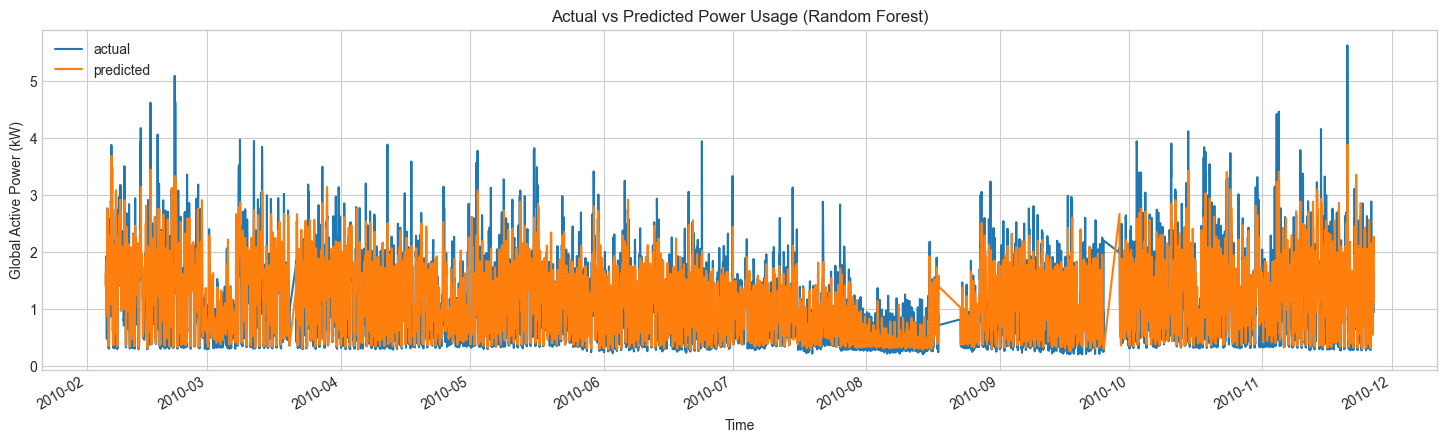

,Model,MAE,RMSE,R2
0,Random Forest,0.333269,0.484273,0.576136
1,Gradient Boosting,0.344975,0.488104,0.569405
2,Linear Regression,0.388521,0.532628,0.487266


In [10]:
best_model_name = results_df.loc[0, "Model"]
best_pred = predictions[best_model_name]

comparison_df = pd.DataFrame(
    {
        "datetime": dates_test,
        "actual": y_test.values,
        "predicted": best_pred,
    }
).set_index("datetime")

fig, ax = plt.subplots(figsize=(18, 5))
comparison_df[["actual", "predicted"]].plot(ax=ax)
ax.set_title(f"Actual vs Predicted Power Usage ({best_model_name})")
ax.set_ylabel("Global Active Power (kW)")
ax.set_xlabel("Time")
plt.show()

results_df

## Peak-Demand Detection

We flag high-load periods where actual demand exceeds the 90th percentile of test-set power usage. This helps identify potential times to activate backup systems or apply demand-side controls.

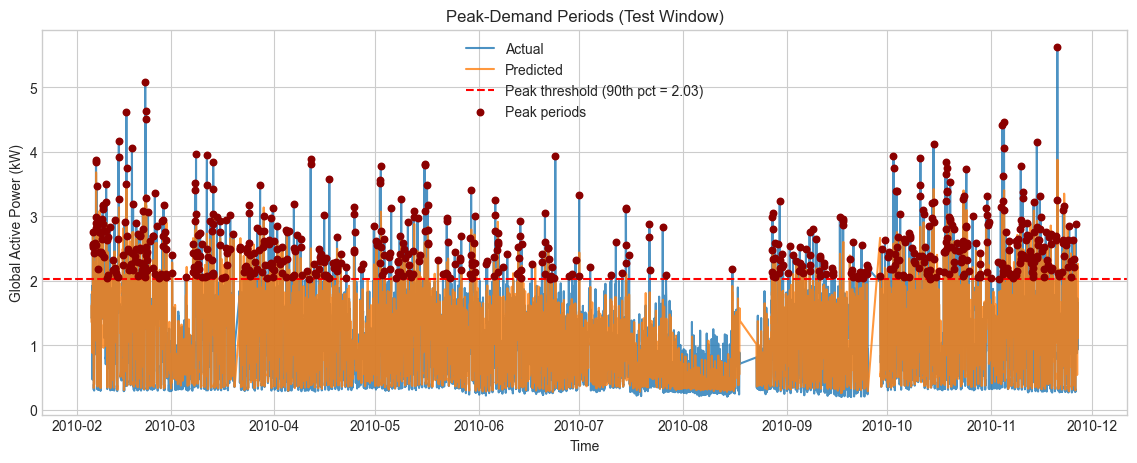

Number of peak periods: 683


,actual,predicted
datetime,,
2010-02-05 18:00:00,2.555133,1.510660
2010-02-05 19:00:00,2.764100,2.752162
2010-02-05 20:00:00,2.565833,2.453820
2010-02-05 21:00:00,2.520700,1.773650
2010-02-06 06:00:00,2.438800,2.086954
2010-02-06 09:00:00,2.579733,1.588480
2010-02-06 14:00:00,2.893133,1.729297
2010-02-06 15:00:00,2.820700,2.161537
2010-02-06 17:00:00,3.877433,2.283459


In [11]:
peak_threshold = comparison_df["actual"].quantile(0.90)
peak_periods = comparison_df[comparison_df["actual"] >= peak_threshold].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(comparison_df.index, comparison_df["actual"], label="Actual", alpha=0.8)
ax.plot(comparison_df.index, comparison_df["predicted"], label="Predicted", alpha=0.8)
ax.axhline(
    peak_threshold,
    color="red",
    linestyle="--",
    label=f"Peak threshold (90th pct = {peak_threshold:.2f})",
)

if not peak_periods.empty:
    ax.scatter(
        peak_periods.index,
        peak_periods["actual"],
        color="darkred",
        s=22,
        label="Peak periods",
        zorder=4,
    )

ax.set_title("Peak-Demand Periods (Test Window)")
ax.set_ylabel("Global Active Power (kW)")
ax.set_xlabel("Time")
ax.legend()
plt.show()

print(f"Number of peak periods: {len(peak_periods)}")
peak_periods.head(10)